# RLlib PPO & SAC на InstantContinuousPipelineEnv

Сравнение с Tianshou: те же алгоритмы (PPO, SAC), та же среда, та же архитектура сетей (`[256, 256]` + LayerNorm), мониторинг градиентов.

Цель — проверить, проблема с взрывом градиентов в алгоритмах или в библиотеке.

In [1]:
import sys
import os
sys.path.insert(0, os.getcwd())

import ray
import numpy as np
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.algorithms.sac import SACConfig
from ray.tune.registry import register_env
from ray.rllib.core.rl_module.default_model_config import DefaultModelConfig

from hpo_rl.environments.instant_continuous_pipeline_env import InstantContinuousPipelineEnv
from hpo_rl.backends.function import OptimizationBenchmarkBackend
from hpo_rl.backends.sequential import SequentialBackend
import torch

## Общие утилиты

1. **Фабрика среды** — создаёт `InstantContinuousPipelineEnv` с `SequentialBackend` (rastrigin + rosenbrock + schwefel, 2D).  
2. **Gradient hook** — навешивается в RLlib-callback после каждого `on_train_result`, собирает статистику по градиентам аналогично `GradientMonitorMixin` из Tianshou-пайплайна.

In [2]:
# ── Конфигурация среды (одинаковая для PPO и SAC) ──────────────────────

ENV_CONFIG = {
    "max_delta_frac": 0.05,
    "max_steps": 200,
    "history_window": 3,
    "reward_mode": "absolute",
}

BACKEND_SPECS = [
    {"function": "rastrigin",  "dimensions": 2},
    {"function": "rosenbrock", "dimensions": 2},
    {"function": "schwefel",   "dimensions": 2},
]


def _make_backend() -> SequentialBackend:
    """Создаёт SequentialBackend(shuffle) из списка бенчмарков."""
    backends = [
        OptimizationBenchmarkBackend(
            function_name=spec["function"],
            dimensions=spec["dimensions"],
            maximize=False,
        )
        for spec in BACKEND_SPECS
    ]
    return SequentialBackend(backends=backends, mode="shuffle")


def _make_hp_space(backend: SequentialBackend) -> dict:
    """Генерирует hp_space по merged bounds первого child бэкенда."""
    child = backend.backends[0]
    lo, hi = child.bounds
    dims = child.dimensions
    return {
        f"x{i}": {"type": "float", "values": [lo, hi]}
        for i in range(dims)
    }


def env_creator(config: dict) -> InstantContinuousPipelineEnv:
    """Фабрика среды для register_env (Ray Tune)."""
    backend = _make_backend()
    hp_space = _make_hp_space(backend)
    env_kwargs = {**ENV_CONFIG, **(config or {})}
    return InstantContinuousPipelineEnv(
        hp_space=hp_space,
        backend=backend,
        **env_kwargs,
    )


register_env("HPO-ContinuousPipeline-v0", env_creator)

In [3]:
# ── RLlib Callback для мониторинга градиентов ──────────────────────────
from ray.rllib.callbacks.callbacks import RLlibCallback


class GradientMonitorCallback(RLlibCallback):
    """Логирует статистику градиентов после каждого training step.

    Аналог GradientMonitorMixin из Tianshou-пайплайна:
    собирает mean/max/norm по каждому параметру и суммарную норму.
    Печатает в stdout каждые `log_interval` обновлений.
    """

    def __init__(self, log_interval: int = 10, verbose: bool = True):
        super().__init__()
        self._log_interval = log_interval
        self._verbose = verbose
        self._step_counter = 0

    def on_train_result(self, *, algorithm, metrics_logger=None, result, **kwargs):
        self._step_counter += 1

        learner_group = algorithm.learner_group
        # Достаём первый (и единственный) learner
        learner = learner_group._learner

        grad_stats = {}
        all_norms = []

        for module_id, rl_module in learner.module.items():
            if not hasattr(rl_module, "named_parameters"):
                continue
            for name, param in rl_module.named_parameters():
                if param.grad is None:
                    continue
                grad = param.grad.detach()
                norm_val = grad.norm().item()
                mean_val = grad.abs().mean().item()
                max_val = grad.abs().max().item()

                prefix = f"grad/{module_id}/{name}"
                grad_stats[f"{prefix}/norm"] = norm_val
                grad_stats[f"{prefix}/mean"] = mean_val
                grad_stats[f"{prefix}/max"] = max_val
                all_norms.append(norm_val)

        if all_norms:
            grad_stats["grad/total_norm_mean"] = float(np.mean(all_norms))
            grad_stats["grad/total_norm_max"] = float(np.max(all_norms))
            grad_stats["grad/total_norm_min"] = float(np.min(all_norms))

        result["custom_metrics"] = result.get("custom_metrics", {})
        result["custom_metrics"].update(grad_stats)

        if self._verbose and self._step_counter % self._log_interval == 0 and all_norms:
            print(f"\n[GradMonitor-RLlib] step {self._step_counter}")
            print(f"  Total grad norm: mean={np.mean(all_norms):.6f}, "
                  f"max={np.max(all_norms):.6f}, min={np.min(all_norms):.6f}")
            sorted_layers = sorted(
                [(k, v) for k, v in grad_stats.items() if k.endswith("/norm")],
                key=lambda x: x[1], reverse=True,
            )
            for layer_name, norm_v in sorted_layers[:5]:
                print(f"  {layer_name}: {norm_v:.6f}")

In [ ]:
# ── Утилита для запуска обучения и печати результатов ──────────────────

def train_and_report(algo, n_iters: int = 50):
    """Обучает algorithm n_iters итераций, печатает reward/loss/grad каждый шаг."""
    best_reward = float("-inf")
    for i in range(1, n_iters + 1):
        result = algo.train()

        er = result.get("env_runners", {})
        ep_return_mean = er.get("episode_return_mean", float("nan"))
        ep_len_mean = er.get("episode_len_mean", float("nan"))

        if not np.isnan(ep_return_mean) and ep_return_mean > best_reward:
            best_reward = ep_return_mean

        # Собираем ключевые метрики learner
        lr_metrics = result.get("learners", {}).get("default_policy", {})
        total_loss = lr_metrics.get("total_loss", float("nan"))
        grad_norms = {k: v for k, v in lr_metrics.items() if "gradient" in k.lower() or "grad_norm" in k.lower()}
        grad_str = "  ".join(f"{k}={v:.4f}" for k, v in grad_norms.items()) if grad_norms else ""

        # Собираем кастомные метрики из callback
        custom = result.get("custom_metrics", {})
        total_norm_max = custom.get("grad/total_norm_max", None)
        cb_str = f"  cb_grad_max={total_norm_max:.4f}" if total_norm_max is not None else ""

        print(
            f"[iter {i:3d}/{n_iters}]  "
            f"ep_return={ep_return_mean:+.4f}  "
            f"ep_len={ep_len_mean:.1f}  "
            f"loss={total_loss:.4f}  "
            f"best={best_reward:+.4f}"
            f"  {grad_str}{cb_str}"
        )

    print(f"\n>>> Training done. Best episode return mean: {best_reward:+.4f}")
    return algo


def run_inference(algo, n_episodes: int = 3):
    """Прогоняет несколько эпизодов в inference-режиме, печатает результат и визуализирует траекторию."""
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.collections import LineCollection
    from mpl_toolkits.mplot3d.art3d import Line3DCollection
    from matplotlib.ticker import MaxNLocator, ScalarFormatter

    env = env_creator({})
    
    # Для нового API stack (Ray 2.50+) извлекаем RLModule
    has_rl_module = hasattr(algo, "get_module")
    if has_rl_module:
        rl_module = algo.get_module()
        if hasattr(rl_module, "eval"):
            rl_module.eval()

    all_episodes_data = []  # list of (history, backend_ref) per episode
            
    for ep in range(n_episodes):
        obs, info = env.reset()

        # Запоминаем активный child backend для этого эпизода
        active_child = env.backend.current_backend
        func_name = getattr(active_child, "function_name", "unknown")

        total_reward = 0.0
        done = False
        history = []  # (config, metric) для каждого шага

        while not done:
            if has_rl_module:
                with torch.no_grad():
                    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                    out = rl_module.forward_inference({"obs": obs_t})
                    action_dim = env.action_space.shape[0]
                    action = out["action_dist_inputs"][0, :action_dim].cpu().numpy()
            else:
                action = algo.compute_single_action(obs, explore=False)
                
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

            step_config = info.get("current_config", info.get("best_config", {}))
            step_metric = info.get("current_metric", info.get("best_metric", float("nan")))
            history.append((dict(step_config), step_metric))

        all_episodes_data.append((history, active_child, func_name))
        print(
            f"[Inference ep {ep+1} | {func_name}] total_reward={total_reward:+.4f}  "
            f"best_metric={info.get('best_metric', float('nan')):.6f}  "
            f"best_config={info.get('best_config', {})}"
        )

    env.close()

    # ── Визуализация каждого эпизода на его бэкенде ───────────────────

    original_plasma = plt.get_cmap("plasma")
    truncated_plasma = mcolors.LinearSegmentedColormap.from_list(
        "truncated_plasma", original_plasma(np.linspace(0, 0.85, 256))
    )

    # Кэш surface-данных по function_name, чтобы не пересчитывать
    surface_cache: dict[str, tuple] = {}

    def _get_surface(child_backend):
        fname = getattr(child_backend, "function_name", "unknown")
        if fname in surface_cache:
            return surface_cache[fname]
        lo, hi = child_backend.bounds
        grid = np.linspace(lo, hi, 100)
        X0, X1 = np.meshgrid(grid, grid)
        Z = np.zeros_like(X0)
        for i in range(X0.shape[0]):
            for j in range(X0.shape[1]):
                Z[i, j] = child_backend.evaluate({"x0": X0[i, j], "x1": X1[i, j]})
        surface_cache[fname] = (X0, X1, Z)
        return X0, X1, Z

    for ep_idx, (history, child, func_name) in enumerate(all_episodes_data):
        if not history:
            continue

        x0_vals = np.array([h[0].get("x0", 0.0) for h in history])
        x1_vals = np.array([h[0].get("x1", 0.0) for h in history])
        metrics = np.array([h[1] for h in history])
        n_points = len(x0_vals)
        colors = np.linspace(0, 1, n_points)

        X0, X1, Z = _get_surface(child)

        fig, (ax1, _) = plt.subplots(1, 2, figsize=(16, 7))

        # ─── 2D contour + trajectory ───
        ax1.contourf(X0, X1, Z, levels=20, cmap="viridis", alpha=0.15)
        contour = ax1.contour(X0, X1, Z, levels=20, cmap="viridis", alpha=0.3)
        ax1.clabel(contour, inline=True, fontsize=8)

        points = np.column_stack([x0_vals, x1_vals]).reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=truncated_plasma, array=colors, linewidth=2.5, zorder=3)
        ax1.add_collection(lc)
        ax1.scatter(x0_vals, x1_vals, c=colors, cmap=truncated_plasma, s=25, edgecolors="none", alpha=0.8, zorder=4)

        ax1.scatter(x0_vals[0], x1_vals[0], c="green", s=100, marker="o", label="Start", zorder=5, edgecolors="white")
        ax1.scatter(x0_vals[-1], x1_vals[-1], c="red", s=120, marker="*", label="End", zorder=5, edgecolors="white")

        best_idx = int(np.argmin(metrics))
        ax1.scatter(x0_vals[best_idx], x1_vals[best_idx], c="cyan", s=150, marker="X", label="Best", zorder=6, edgecolors="black")
        ax1.set_title(f"Episode {ep_idx+1} — {func_name} — 2D Trajectory")
        ax1.set_aspect("equal")
        ax1.legend()

        # ─── 3D surface + trajectory ───
        ax2 = fig.add_subplot(122, projection="3d")
        ax2.plot_surface(X0, X1, Z, cmap="viridis", alpha=0.3, linewidth=0, antialiased=True)

        pts3d = np.column_stack([x0_vals, x1_vals, metrics]).reshape(-1, 1, 3)
        seg3d = np.concatenate([pts3d[:-1], pts3d[1:]], axis=1)
        lc3d = Line3DCollection(seg3d, cmap=truncated_plasma, array=colors, linewidth=3)
        ax2.add_collection3d(lc3d)
        ax2.scatter(x0_vals, x1_vals, metrics, c=colors, cmap=truncated_plasma, s=30, depthshade=False)
        ax2.scatter(x0_vals[0], x1_vals[0], metrics[0], c="green", s=100, marker="o", edgecolors="white")
        ax2.scatter(x0_vals[-1], x1_vals[-1], metrics[-1], c="red", s=130, marker="*", edgecolors="white")
        ax2.scatter(x0_vals[best_idx], x1_vals[best_idx], metrics[best_idx], c="cyan", s=150, marker="X", edgecolors="black")
        ax2.set_title(f"{func_name} — 3D View")
        plt.tight_layout()
        plt.show()

        # ─── Optimization history ───
        best_so_far = np.minimum.accumulate(metrics)
        iterations = range(1, n_points + 1)
        fig2, ax3 = plt.subplots(figsize=(10, 6))
        ax3.plot(iterations, metrics, marker="o", markersize=4, linestyle="-", color="blue", alpha=0.3, label=r"$f(x)$")
        ax3.plot(iterations, best_so_far, color="red", linewidth=2, label="Best so far (min)")
        ax3.set_title(f"Episode {ep_idx+1} — {func_name} — Optimization History")
        ax3.set_xlabel("Step")
        ax3.set_ylabel("Objective")
        ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax3.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        ax3.legend()
        plt.tight_layout()
        plt.show()

## PPO (Continuous)

Полный аналог `config_continuous_ppo` из `run_experiment.ipynb`:
- **Сеть**: `[256, 256]`, активация `relu` (RLlib не поддерживает LayerNorm из коробки в default model — будет использован `fcnet_hiddens`)
- **gamma**: 0.99, **entropy_coeff**: 0.05, **grad_clip**: 0.5, **lr**: 3e-4
- **GAE lambda**: 0.95, **vf_loss_coeff**: 0.5, **clip_param**: 0.2
- **train_batch**: 4000, **minibatch**: 64, **sgd_iters**: 10
- **num_env_runners**: 4 (вместо 20 — RLlib сам vectorized, каждый runner имеет несколько envs)

In [5]:
# ── PPO Config ─────────────────────────────────────────────────────────

ray.init(ignore_reinit_error=True)

# obs_dim = 2 params + 4 base + 3 * (2+1) history = 15
# action_dim = 2 (continuous, Box[-1,1])

ppo_config = (
    PPOConfig()
    .environment(
        env="HPO-ContinuousPipeline-v0",
        env_config={},
    )
    .env_runners(
        num_env_runners=4,
        num_envs_per_env_runner=5,     # 4*5 = 20 параллельных сред (≈ num_training_envs=20 в Tianshou)
        rollout_fragment_length="auto",
    )
    .training(
        gamma=0.99,
        lambda_=0.95,
        lr=3e-4,
        entropy_coeff=0.05,
        vf_loss_coeff=0.5,
        clip_param=0.2,
        #grad_clip=0.5,
        train_batch_size_per_learner=4000,
        minibatch_size=64,
        num_epochs=10,                  # SGD passes per batch (= update_step_num_repetitions)
        use_gae=True,
        use_critic=True,
    )
    .rl_module(
        model_config=DefaultModelConfig(
            fcnet_hiddens=[256, 256],
            fcnet_activation="relu",
            vf_share_layers=False,
        ),
    )
    .learners(num_learners=0)  # 0 = local learner (single GPU/CPU)
    .callbacks(GradientMonitorCallback)
    .reporting(
        min_time_s_per_iteration=0,
        min_sample_timesteps_per_iteration=0,
    )
)

ppo_algo = ppo_config.build_algo()
print("PPO algo built successfully")
_env = env_creator({})
print(f"  observation_space: {_env.observation_space}")
print(f"  action_space:      {_env.action_space}")
_env.close()
del _env

2026-03-05 15:51:17,999	INFO worker.py:2013 -- Started a local Ray instance.
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-03-05 15:51:21,970	WARNING algorithm_config.py:5131 -- You are running PPO on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This 

(SingleAgentEnvRunner pid=3208) rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
(SingleAgentEnvRunner pid=3208) rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
(SingleAgentEnvRunner pid=3208) schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
(SingleAgentEnvRunner pid=3208) [SequentialBackend] New shuffle order: rosenbrock, schwefel, rastrigin
(SingleAgentEnvRunner pid=3208) SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
(SingleAgentEnvRunner pid=3208) rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
(SingleAgentEnvRunner pid=3208) rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
(SingleAgentEnvRunner pid=3208) schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
(SingleAgentEnvRunner pid=3208) [SequentialBackend] New shuffle order: rosenbrock, schwefel, rastrigin
(SingleAgentEnvRunner pid=3208) SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
(SingleAgentEnvRunner pid=3208) rastrigin: dims=2, bounds=

(SingleAgentEnvRunner pid=3208) DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
2026-03-05 15:51:30,554	WARNING rl_module.py:463 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
2026-03-05 15:51:33,434	INFO trainable.py:161 -- Trainable.setup took 11.373 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.
2026-03-05 15:51:33,437	WARNING util.py:62 -- Install gputil for GPU system monitoring.


PPO algo built successfully
rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
[SequentialBackend] New shuffle order: schwefel, rosenbrock, rastrigin
SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
  observation_space: Box(-inf, inf, (15,), float32)
  action_space:      Box(-1.0, 1.0, (2,), float32)


In [10]:
# ── PPO Training (50 iterations) ───────────────────────────────────────
ppo_algo = train_and_report(ppo_algo, n_iters=10)

[iter   1/10]  ep_return=-766.3525  ep_len=200.0  loss=4.8801  best=-766.3525    cb_grad_max=2.1858
[iter   2/10]  ep_return=-756.8667  ep_len=200.0  loss=4.7452  best=-756.8667    cb_grad_max=2.6839
[iter   3/10]  ep_return=-763.5130  ep_len=200.0  loss=4.5411  best=-756.8667    cb_grad_max=6.6757
[iter   4/10]  ep_return=-764.8628  ep_len=200.0  loss=4.7054  best=-756.8667    cb_grad_max=5.9951
[iter   5/10]  ep_return=-754.8540  ep_len=200.0  loss=4.7236  best=-754.8540    cb_grad_max=17.9947
[iter   6/10]  ep_return=-761.4607  ep_len=200.0  loss=4.4203  best=-754.8540    cb_grad_max=41.6532
[iter   7/10]  ep_return=-756.7990  ep_len=200.0  loss=4.6667  best=-754.8540    cb_grad_max=25.8706
[iter   8/10]  ep_return=-752.2162  ep_len=200.0  loss=4.7057  best=-752.2162    cb_grad_max=4.8164

[GradMonitor-RLlib] step 30
  Total grad norm: mean=3.946680, max=23.688272, min=0.034832
  grad/default_policy/vf.net.mlp.0.weight/norm: 23.688272
  grad/default_policy/encoder.critic_encoder.net

rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
[SequentialBackend] New shuffle order: rosenbrock, rastrigin, schwefel
SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
[Inference ep 1 | rastrigin] total_reward=-592.8716  best_metric=2.907857  best_config={'x0': -0.09606499384056874, 'x1': -0.9686519632732733}
[Inference ep 2 | rastrigin] total_reward=-585.3904  best_metric=5.104155  best_config={'x0': 0.9287524690541017, 'x1': -0.1318303300074154}
[Inference ep 3 | rastrigin] total_reward=-602.4959  best_metric=5.559204  best_config={'x0': -0.14845576822493284, 'x1': -0.0878623411307379}


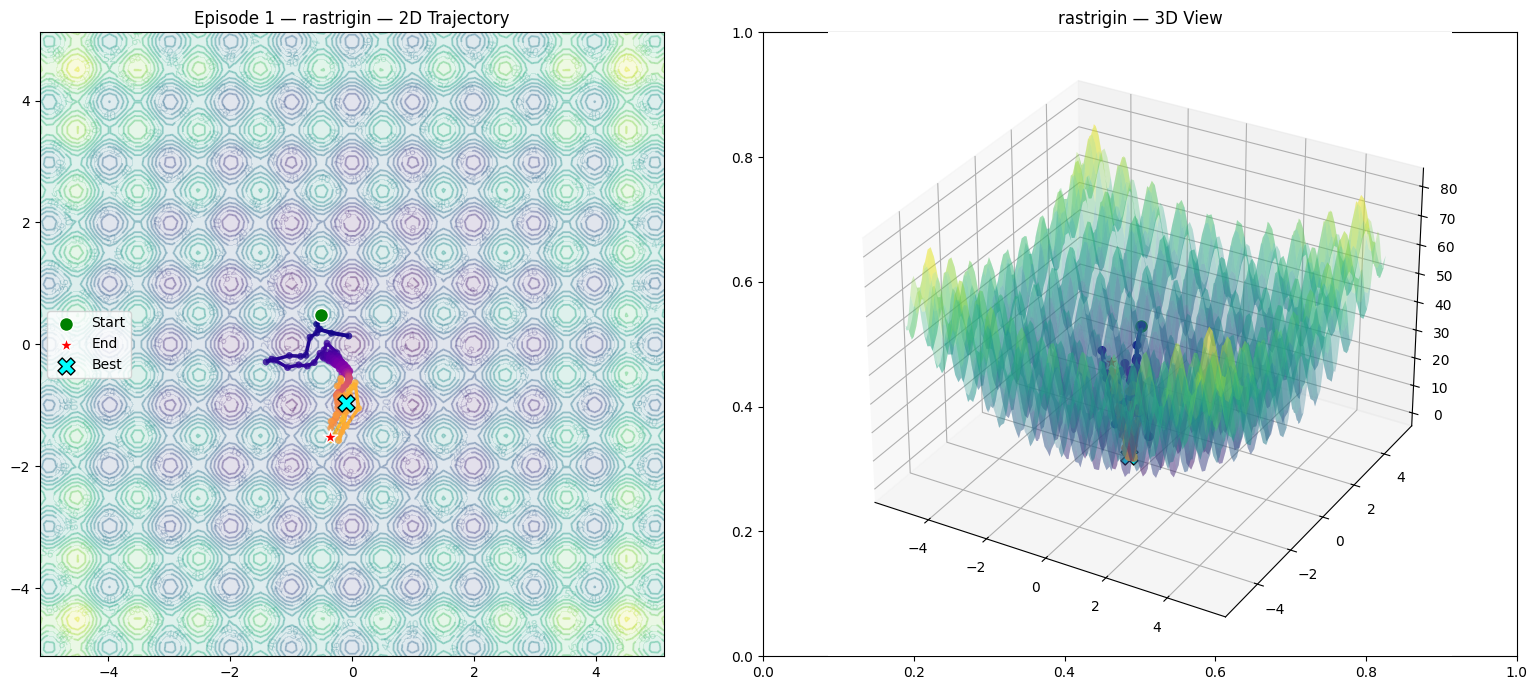

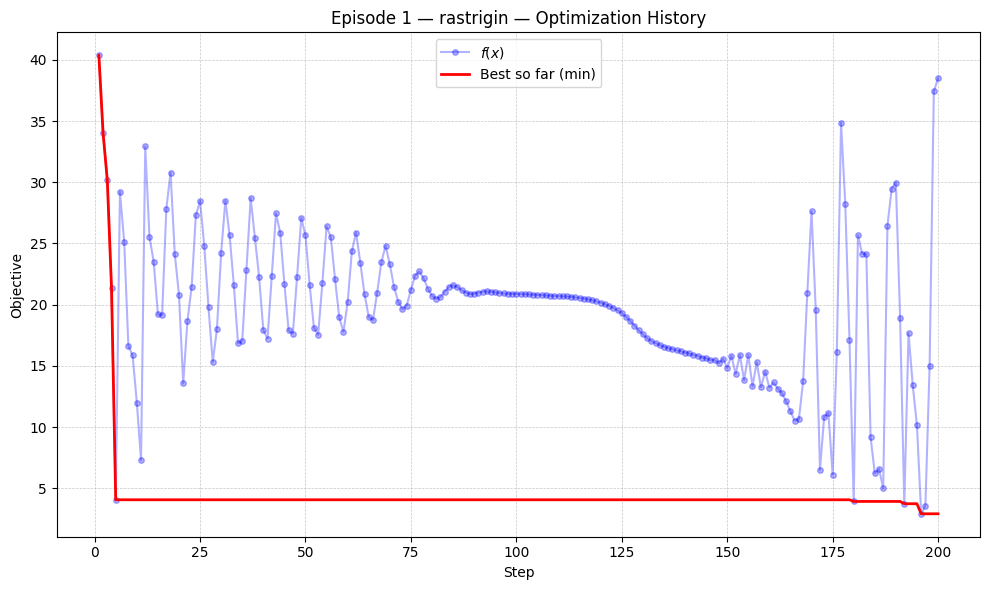

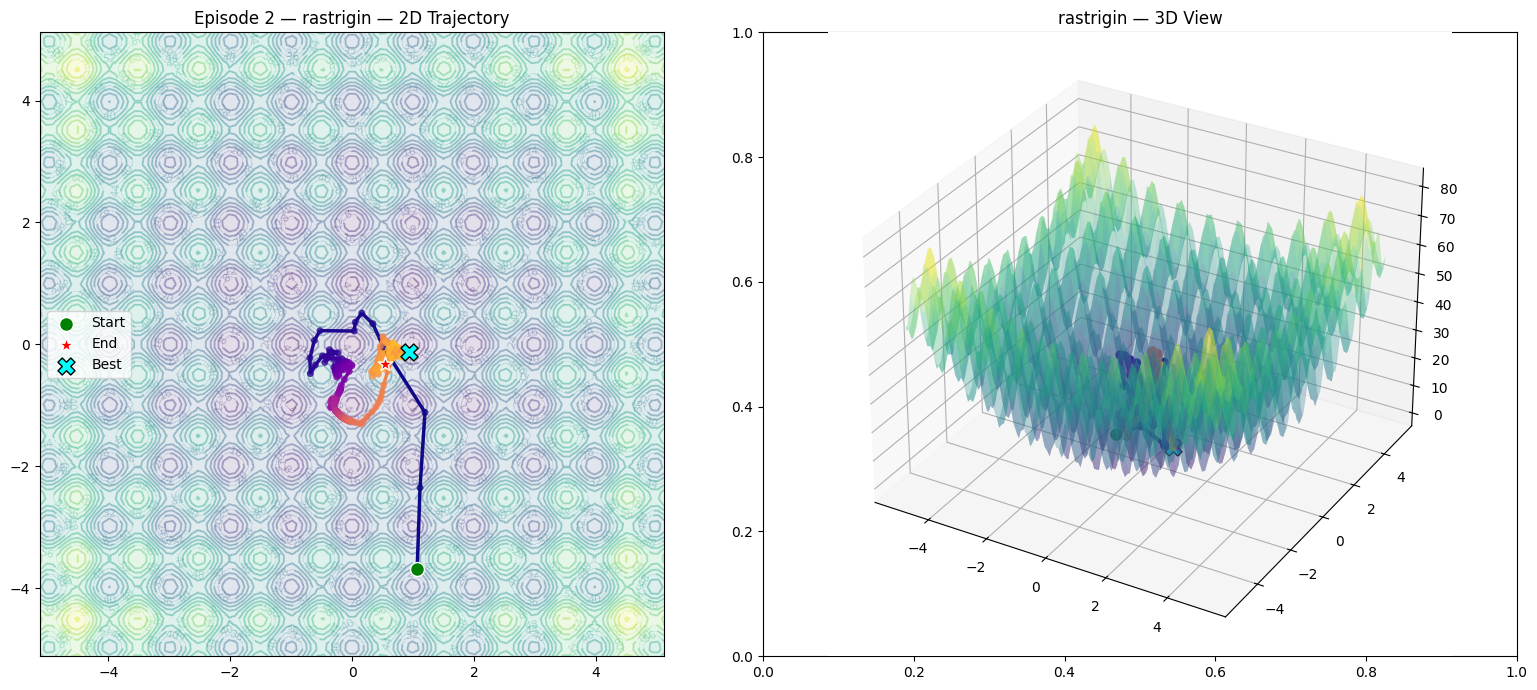

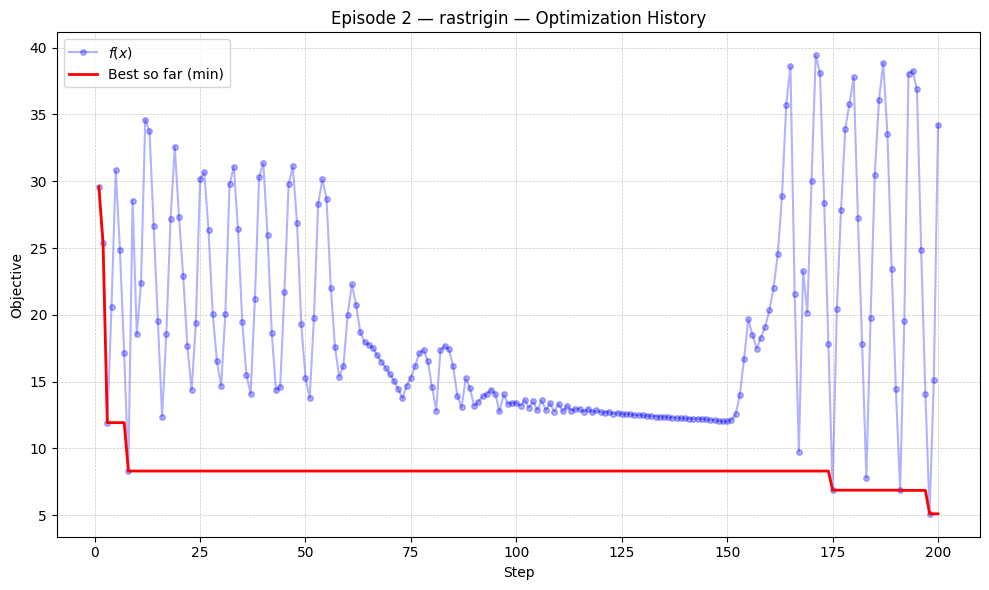

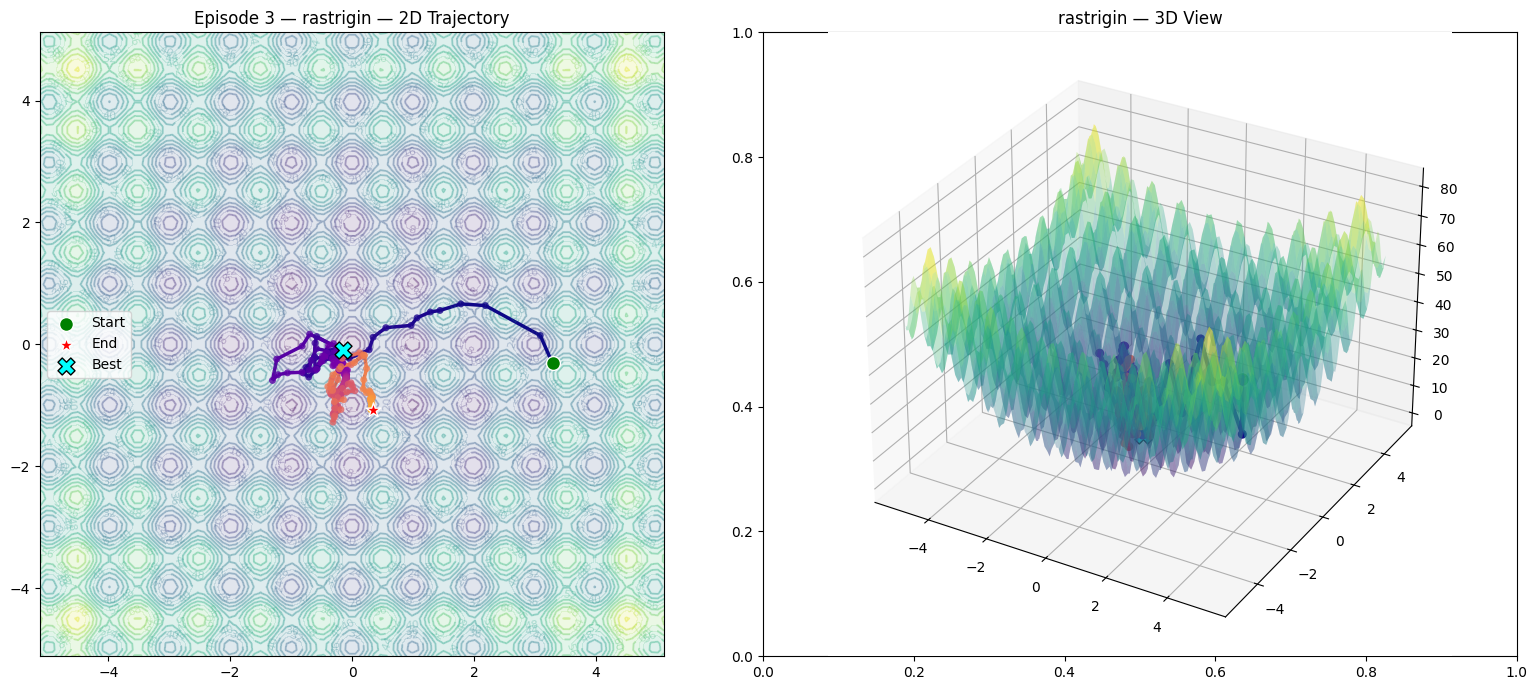

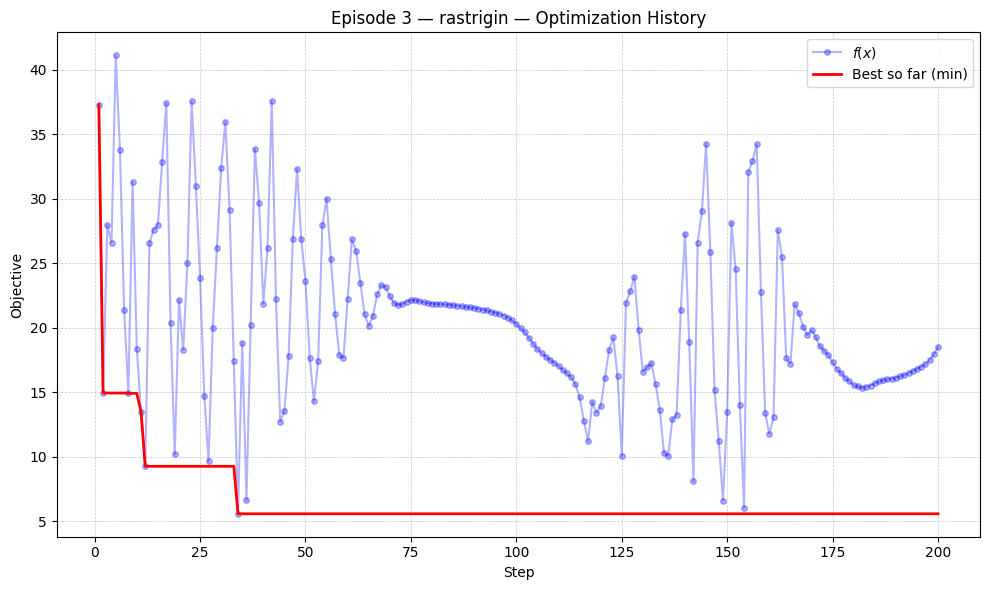

In [24]:
# ── PPO Inference ──────────────────────────────────────────────────────
run_inference(ppo_algo, n_episodes=3)

## SAC (Continuous)

Полный аналог `config_continuous_sac` из `run_experiment.ipynb`:
- **Сеть**: `[256, 256]` (policy и Q-net)
- **gamma**: 0.99, **tau**: 0.005, **auto-alpha** (target_entropy = "auto" → −dim(A) = −2)
- **actor_lr**: 3e-4, **critic_lr**: 3e-4, **alpha_lr**: 3e-4
- **replay_buffer**: 100k, **train_batch**: 256, **n_step**: 1
- **num_env_runners**: 4 × 5 = 20 параллельных сред

In [ ]:
# ── SAC Config ─────────────────────────────────────────────────────────

sac_config = (
    SACConfig()
    .environment(
        env="HPO-ContinuousPipeline-v0",
        env_config={},
    )
    .env_runners(
        num_env_runners=4,
        num_envs_per_env_runner=5,     # 4*5 = 20 параллельных сред
        rollout_fragment_length=1,
    )
    .training(
        gamma=0.99,
        tau=0.005,
        initial_alpha=1.0,
        target_entropy="auto",           # → -dim(A) = -2
        actor_lr=3e-4,
        critic_lr=3e-4,
        alpha_lr=3e-4,
        n_step=1,
        train_batch_size_per_learner=256,
        twin_q=True,
        replay_buffer_config={
            "type": "PrioritizedEpisodeReplayBuffer",
            "capacity": 100_000,
        },
        num_steps_sampled_before_learning_starts=2000,
        #grad_clip=0.5,
    )
    .rl_module(
        model_config=DefaultModelConfig(
            fcnet_hiddens=[256, 256],
            fcnet_activation="relu",
        ),
    )
    .learners(num_learners=0)
    .callbacks(GradientMonitorCallback)
    .reporting(
        min_time_s_per_iteration=0,
        min_sample_timesteps_per_iteration=0,
    )
)

sac_algo = sac_config.build_algo()
print("SAC algo built successfully")

In [ ]:
# ── SAC Training (50 iterations ≈ 15 epochs из Tianshou при 4000 steps/epoch) ──
sac_algo = train_and_report(sac_algo, n_iters=50)

In [ ]:
# ── SAC Inference ──────────────────────────────────────────────────────
run_inference(sac_algo, n_episodes=3)

In [ ]:
# ── Cleanup (вызывать только когда полностью закончил) ─────────────────
ppo_algo.stop()
sac_algo.stop()
ray.shutdown()
print("All algorithms stopped. Ray shutdown complete.")